In [1]:
import re
import numpy as np
import pandas as pd
from openai import OpenAI
from tqdm.auto import tqdm

In [2]:
# df = pd.read_parquet("data/processbench.parquet")

# df_inc = df[df["label"]!=-1]
# df_inc["roi_step_num"] = df_inc["label"]
# df_inc["roi_step"] = df_inc.T.apply(lambda x: x.steps[x.roi_step_num]).values


# df_cor = df[df["label"]==-1]
# df_cor["roi_step_num"] = df_cor["steps_len"].apply(lambda x: np.random.choice(x))
# df_cor["roi_step"] = df_cor.T.apply(lambda x: x.steps[x.roi_step_num]).values

# pd.concat([df_inc, df_cor]).to_parquet("data/processbench_with_roi.parquet")

In [3]:
df = pd.read_parquet("data/processbench_with_roi.parquet")

```bash
vllm serve hf_cache/Qwen--Qwen2.5-7B-Instruct \
    --host 0.0.0.0 \
    --port 8081 \
    --gpu-memory-utilization 0.85 \
    --enable-prefix-caching \
    --dtype bfloat16 \
    --max_model_len 8000
```

### Analysis

In [ ]:
openai_api_key = "EMPTY"
openai_api_base = "http://localhost:8081/v1"
client = OpenAI(
    api_key=openai_api_key,
    base_url=openai_api_base,
)
models = client.models.list()
model = models.data[0].id

In [104]:
# PROMPT_VERBOSE = """<step> {STEP} </step>

# Task: Expand the step to make it more verbose. Assume this step is part of a multi-step mathematical reasoning process.

# Output Format:
# <response> {{YOUR RESPONSE HERE}} </response>
# """

PROMPT_VERBOSE = """<step> {STEP} </step>

Task: Expand the step to make it more verbose. Assume this step is part of a multi-step mathematical reasoning process.

Notes:
1. Do not break the step into multiple paragraphs or lines.
2. Ensure that no additional theorems, equations or assumptions are introduced.
3. If expansion is not possible, return the original step.
4. Follow the structure of the original step.
5. Enclose your response inside <response> tags.

Output Format:
<response> {{YOUR RESPONSE HERE}} </response>
"""

PROMPT_CONSISE = """<step> {STEP} </step>

Task: Make the step more concise, while keeping all the information intact. Assume this step is part of a multi-step mathematical reasoning process.

Output Format:
<response> {{YOUR RESPONSE HERE}} </response>
"""

PROMPT_EQ_TO_TEXT = """<step> {STEP} </step>

Task: Convert all mathematical equations, numbers and symbols in the step to fully written-out text. Spell out the equations, numbers and symbols clearly as if explaining them in words. Assume this step is part of a larger multi-step mathematical reasoning process.

Output Format:
<response> {{YOUR RESPONSE HERE}} </response>
"""

PROMPT_CHANGE_NUMBERS = """<step> {STEP} </step>

Task: Replace all the numbers with random values such that the resulting equations is mathematically incorrect. The structure (e.g., operations, variables) of the equation and step should remain the same. 

Note: Do not indicate to the user that the modified equation is incorrect. Assume this step is part of a broader multi-step mathematical reasoning process.

Output Format:
<response> {{YOUR RESPONSE HERE}} </response>
"""

In [105]:
from tqdm.auto import tqdm
from multiprocessing import Pool, cpu_count

def process_sample(incorrect_step):
    # Verbose
    try:
        verbose_text = client.chat.completions.create(
            messages=[
                {"role": "user", "content": PROMPT_VERBOSE.format(STEP=incorrect_step)},
            ],
            model=model,
        ).choices[0].message.content
        verbose_result = re.findall(r"<response>(.*?)</response>", verbose_text, re.DOTALL)[0].strip()
    except Exception as e:
        print(f"Error (Verbose): {e}")
        print(f"Verbose Text: {verbose_text}")
        print("#"*25)
        verbose_result = incorrect_step

    return verbose_result, _, _, _
    # # Consise
    # try:Enclose your response inside <response>
    #     consise_text = client.chat.completions.create(
    #         messages=[
    #             {"role": "user", "content": PROMPT_CONSISE.format(STEP=incorrect_step)},
    #         ],
    #         model=model,
    #     ).choices[0].message.content
    #     consise_result = re.findall(r"<response>(.*?)</response>", consise_text, re.DOTALL)[0].strip()
    # except Exception as e:
    #     print(f"Error (Consise): {e}")
    #     consise_result = incorrect_step

    # # Equation to Text
    # try:
    #     spelled_eq_text = client.chat.completions.create(
    #         messages=[
    #             {"role": "user", "content": PROMPT_EQ_TO_TEXT.format(STEP=incorrect_step)},
    #         ],
    #         model=model,
    #     ).choices[0].message.content
    #     spelled_eq_result = re.findall(r"<response>(.*?)</response>", spelled_eq_text, re.DOTALL)[0].strip()
    # except Exception as e:
    #     print(f"Error (Equation to text): {e}")
    #     spelled_eq_result = incorrect_step

    # # Equation to Text
    # try:
    #     change_numbers_text = client.chat.completions.create(
    #         messages=[
    #             {"role": "user", "content": PROMPT_CHANGE_NUMBERS.format(STEP=incorrect_step)},
    #         ],
    #         model=model,
    #     ).choices[0].message.content
    #     change_numbers_result = re.findall(r"<response>(.*?)</response>", change_numbers_text, re.DOTALL)[0].strip()
    # except Exception as e:
    #     print(f"Error (Change numbers): {e}")
    #     change_numbers_result = incorrect_step

    # return verbose_result, consise_result, spelled_eq_result, change_numbers_result

In [107]:
# Use multiprocessing to process each sample
num_workers = cpu_count()
with Pool(num_workers) as pool:
    results = list(tqdm(pool.imap(process_sample, df["roi_step"].values), total=len(df)))

# Combine results
verbose_roi_step, consise_roi_step, spelled_eq_roi_step, change_numbers_roi_step = zip(*results)
verbose_roi_step = list(verbose_roi_step)
# consise_roi_step = list(consise_roi_step)
# spelled_eq_roi_step = list(spelled_eq_roi_step)
# change_numbers_roi_step = list(change_numbers_roi_step)

df["verbose_roi_step_v2"] = verbose_roi_step
# df["consise_roi_step"] = consise_roi_step
# df["spelled_eq_roi_step"] = spelled_eq_roi_step
# df["change_numbers_roi_step"] = change_numbers_roi_step

verbose_steps = []
consise_steps = []
spelled_eq_steps = []
change_numbers_steps = []
for idx, row in df.iterrows():
    steps = row["steps"].copy()

    steps[row["roi_step_num"]] = row["verbose_roi_step_v2"]
    verbose_steps.append(steps.copy())

    # steps[row["roi_step_num"]] = row["consise_roi_step"]
    # consise_steps.append(steps.copy())
    
    # steps[row["roi_step_num"]] = row["spelled_eq_roi_step"]
    # spelled_eq_steps.append(steps.copy())\( M \) is the number of \( k \)-step sequences that achieve the desired state without touching lamps \( n+1 \) through \( 2n \) at all. This means we only switch lamps 1 through \( n \). Since we need exactly \( n \) of these lamps to be on after \( k \) steps, and since each step switches one lamp, \( k \) must be odd (because \( n \) is odd and we start with all lamps off). The number of ways to achieve this is the number of sequences of length \( k \) that result in each of the first \( n \) lamps being toggled an odd number of times. This is equivalent to finding the number of solutions to the equation \( x_1 + x_2 + \cdots + x_n = k \) where each \( x_i \) is odd.


    # steps[row["roi_step_num"]] = row["change_numbers_roi_step"]
    # change_numbers_steps.append(steps.copy())

df["verbose_steps_v2"] = verbose_steps
# df["consise_steps"] = consise_steps
# df["spelled_eq_steps"] = spelled_eq_steps
# df["change_numbers_steps"] = change_numbers_steps

# df.to_parquet("data/processbench_with_roi.parquet")

  0%|          | 0/100 [00:00<?, ?it/s]

In [118]:
idx = 95
print(df["verbose_roi_step_v2"].iloc[idx])

The roots of this polynomial are \(\pm \tan \left(\frac{\pi}{7}\right), \pm \tan \left(\frac{2\pi}{7}\right), \pm \tan \left(\frac{3\pi}{7}\right)\), and their counterparts \(\pm \tan \left(\frac{4\pi}{7}\right), \pm \tan \left(\frac{5\pi}{7}\right), \pm \tan \left(\frac{6\pi}{7}\right)\) which are simply \(-\tan \left(\frac{3\pi}{7}\right), -\tan \left(\frac{2\pi}{7}\right), -\tan \left(\frac{\pi}{7}\right)\), \(-\tan \left(\frac{3\pi}{7}\right), -\tan \left(\frac{2\pi}{7}\right), -\tan \left(\frac{\pi}{7}\right)\) respectively due to the periodic and symmetric properties of the tangent function. The product of the roots of the polynomial \(P(x)\) is given by the constant term divided by the leading coefficient, with a sign change if the degree is even. This results in the product of all roots being:
\[ \tan \left(\frac{\pi}{7}\right) \tan \left(\frac{2\pi}{7}\right) \tan \left(\frac{3\pi}{7}\right) \cdot \tan \left(\frac{4\pi}{7}\right) \tan \left(\frac{5\pi}{7}\right) \tan \left(\fr

In [119]:
print(df["roi_step"].iloc[idx])

The roots of this polynomial are \(\pm \tan \left(\frac{\pi}{7}\right), \pm \tan \left(\frac{2\pi}{7}\right), \pm \tan \left(\frac{3\pi}{7}\right)\). The product of the roots of the polynomial \(P(x)\) is given by the constant term divided by the leading coefficient, with a sign change if the degree is even:
\[ \tan \left(\frac{\pi}{7}\right) \tan \left(\frac{2\pi}{7}\right) \tan \left(\frac{3\pi}{7}\right) \cdot \tan \left(\frac{4\pi}{7}\right) \tan \left(\frac{5\pi}{7}\right) \tan \left(\frac{6\pi}{7}\right) = \sqrt{7}. \]


### Plots

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("data/processbench_with_roi.parquet")
df = df[df["label"]!=-1]

In [29]:
df.keys()

Index(['id', 'generator', 'problem', 'steps', 'final_answer_correct', 'label',
       'split', 'steps_len', 'per_step_len', 'Qwen2.5-Math-PRM-7B',
       'Skywork-o1-Open-PRM-Qwen-2.5-7B', 'roi_step_num', 'roi_step',
       'verbose_roi_step', 'consise_roi_step', 'spelled_eq_roi_step',
       'verbose_steps', 'consise_steps', 'spelled_eq_steps',
       'Skywork-o1-Open-PRM-Qwen-2.5-7B--spelled_eq_steps',
       'Skywork-o1-Open-PRM-Qwen-2.5-7B--consise_steps',
       'Skywork-o1-Open-PRM-Qwen-2.5-7B--verbose_steps',
       'Qwen2.5-Math-PRM-7B--verbose_steps',
       'Qwen2.5-Math-PRM-7B--consise_steps',
       'Qwen2.5-Math-PRM-7B--spelled_eq_steps', 'change_numbers_roi_step',
       'change_numbers_steps',
       'Skywork-o1-Open-PRM-Qwen-2.5-7B--change_numbers_steps',
       'Qwen2.5-Math-PRM-7B--change_numbers_steps'],
      dtype='object')

In [30]:
def visualize(row, model="Skywork-o1-Open-PRM-Qwen-2.5-7B"):
    row = row.iloc[0]
    roi_step = row["roi_step_num"]
    print(roi_step)
    print("#### Original Step #### Score:", row[model][roi_step])
    print(row["roi_step"])
    print()
    print("#### Verbose Step #### Score:", row[model+"--verbose_steps"][roi_step])
    print(row["verbose_roi_step"])
    print()

    print("#### Consise Step #### Score:", row[model+"--consise_steps"][roi_step])
    print(row["consise_roi_step"])
    print()

    print("#### Spelled Equation #### Score:", row[model+"--spelled_eq_steps"][roi_step])
    print(row["spelled_eq_roi_step"])
    print()

    print("#### Change numbers to incorrect #### Score:", row[model+"--change_numbers_steps"][roi_step])
    print(row["change_numbers_roi_step"])
    print()

In [31]:
visualize(df.sample(), "Qwen2.5-Math-PRM-7B")

2
#### Original Step #### Score: 0.0198974609375
Since the determinant is non-zero, the inverse exists. Now, we will find the cofactor matrix of \(\mathbf{A}\). The cofactors are:
- First, \(C_{11} = (-2)^{-1} = -0.5\)
- Second, \(C_{12} = -(13)^{-1} = -0.0769\) (approximately)
- Third, \(C_{21} = -(7)^{-1} = -0.1429\) (approximately)
- Fourth, \(C_{22} = (2)^{-1} = 0.5\)

#### Verbose Step #### Score: 0.04150390625
Since the determinant of the matrix \(\mathbf{A}\) is non-zero, the inverse of \(\mathbf{A}\) exists. To find the inverse, we first need to determine the cofactor matrix of \(\mathbf{A}\). The cofactor matrix is obtained by calculating the cofactors for each element of \(\mathbf{A}\). The cofactor \(C_{ij}\) of an element \(a_{ij}\) is given by \(C_{ij} = (-1)^{i+j} \cdot M_{ij}\), where \(M_{ij}\) is the minor of the element \(a_{ij}\).

Let's calculate the cofactors for each element of \(\mathbf{A}\):

1. For \(a_{11}\), the element in the first row and first column, the 

In [32]:
verbose_steps_o1 = df.T.apply(lambda x: x["Skywork-o1-Open-PRM-Qwen-2.5-7B--verbose_steps"][x.roi_step_num]).values
consise_steps_o1 = df.T.apply(lambda x: x["Skywork-o1-Open-PRM-Qwen-2.5-7B--consise_steps"][x.roi_step_num]).values
spelled_eq_steps_o1 = df.T.apply(lambda x: x["Skywork-o1-Open-PRM-Qwen-2.5-7B--spelled_eq_steps"][x.roi_step_num]).values
steps_o1 = df.T.apply(lambda x: x["Skywork-o1-Open-PRM-Qwen-2.5-7B"][x.roi_step_num]).values

verbose_steps_qwen_prm = df.T.apply(lambda x: x["Qwen2.5-Math-PRM-7B--verbose_steps"][x.roi_step_num]).values
consise_steps_qwen_prm = df.T.apply(lambda x: x["Qwen2.5-Math-PRM-7B--consise_steps"][x.roi_step_num]).values
spelled_eq_steps_qwen_prm = df.T.apply(lambda x: x["Qwen2.5-Math-PRM-7B--spelled_eq_steps"][x.roi_step_num]).values
steps_qwen_prm = df.T.apply(lambda x: x["Qwen2.5-Math-PRM-7B"][x.roi_step_num]).values

In [33]:
from scipy.stats import norm, t

def statistical_test(mean_change, std_dev, sample_size=1000):
    alpha = 0.05

    # Exact critical value using t-distribution
    degrees_of_freedom = sample_size - 1
    t_critical = t.ppf(1 - alpha / 2, degrees_of_freedom)
    
    # Calculate standard error
    sem = std_dev / sample_size ** 0.5
    
    # Calculate t-statistic
    t_statistic = mean_change / sem
    print(f"T-statistic: {t_statistic:.4f} (Critical value {t_critical:.4f})")
    
    # Calculate p-value
    p_value = 2 * (1 - t.cdf(abs(t_statistic), df=degrees_of_freedom))
    print(f"P-value: {p_value:.6f}")
    
    # Check significance (two-tailed test!)
    if abs(t_statistic) < t_critical:
        print("Result: Not statistically significant")
    else:
        print("Result: Statistically significant")
    

    # Interpretation of p-value
    if p_value <= alpha:
        print("Interpretation: The result is statistically significant (reject the null hypothesis).")
    else:
        print("Interpretation: The result is not statistically significant (fail to reject the null hypothesis).")


In [34]:
def plot_stats(modified_step_score, original_step_score):
    relative_change = (modified_step_score-original_step_score)#/original_step_score

    mean_relative_change = np.mean(relative_change)
    std_relative_change = np.std(relative_change)
    statistical_test(mean_relative_change, std_relative_change)
    print()

    print("Relative mean change:", mean_relative_change)
    print("Relative std change:", std_relative_change)
    plt.hist(relative_change, bins=100)
    plt.plot()
    print()

T-statistic: -5.9508 (Critical value 1.9623)
P-value: 0.000000
Result: Statistically significant
Interpretation: The result is statistically significant (reject the null hypothesis).

Relative mean change: -0.022117524249709475
Relative std change: 0.11753429541719924



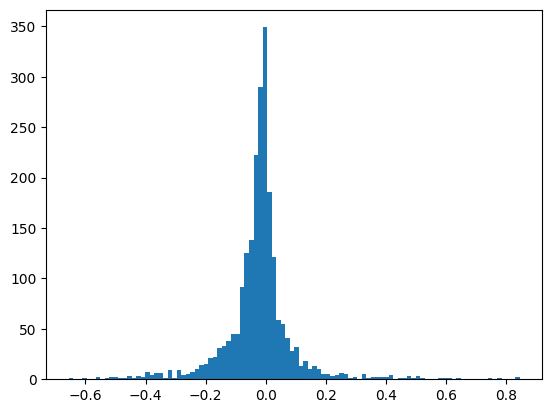

In [35]:
plot_stats(consise_steps_o1, steps_o1)

T-statistic: 1.6482 (Critical value 1.9623)
P-value: 0.099636
Result: Not statistically significant
Interpretation: The result is not statistically significant (fail to reject the null hypothesis).

Relative mean change: 0.014608959419563083
Relative std change: 0.28029902702947374



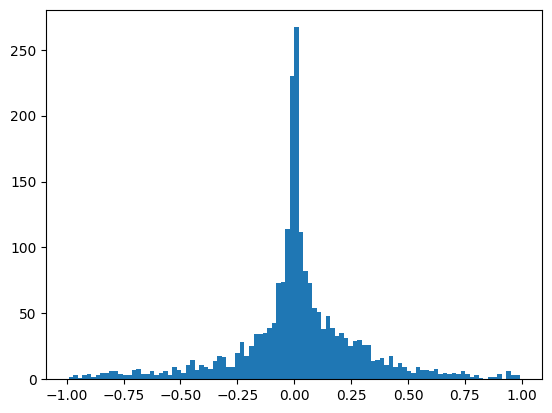

In [36]:
plot_stats(consise_steps_qwen_prm, steps_qwen_prm)

T-statistic: -8.1741 (Critical value 1.9623)
P-value: 0.000000
Result: Statistically significant
Interpretation: The result is statistically significant (reject the null hypothesis).

Relative mean change: -0.04463250581553639
Relative std change: 0.17266794618497133



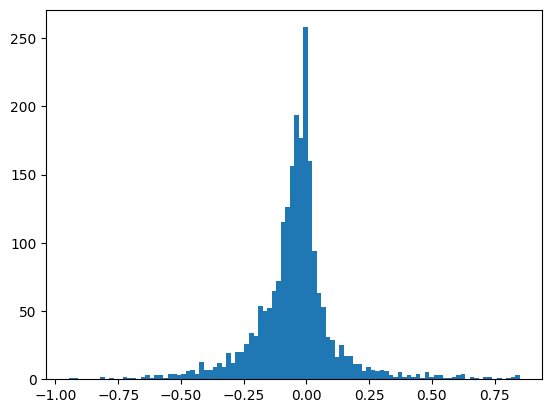

In [37]:
plot_stats(verbose_steps_o1, steps_o1)

T-statistic: -13.4998 (Critical value 1.9623)
P-value: 0.000000
Result: Statistically significant
Interpretation: The result is statistically significant (reject the null hypothesis).

Relative mean change: -0.13454351721449728
Relative std change: 0.3151631928690283



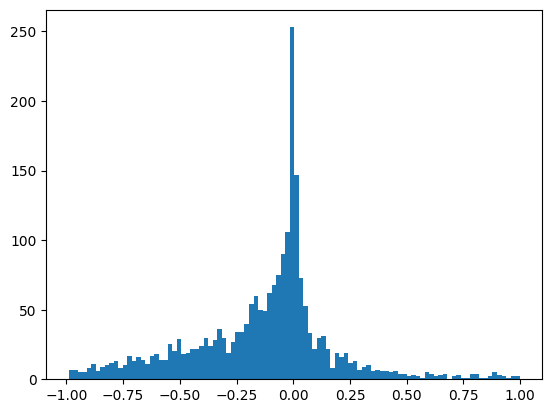

In [38]:
plot_stats(verbose_steps_qwen_prm, steps_qwen_prm)

T-statistic: -5.4360 (Critical value 1.9623)
P-value: 0.000000
Result: Statistically significant
Interpretation: The result is statistically significant (reject the null hypothesis).

Relative mean change: -0.019920532543608573
Relative std change: 0.1158836365432009



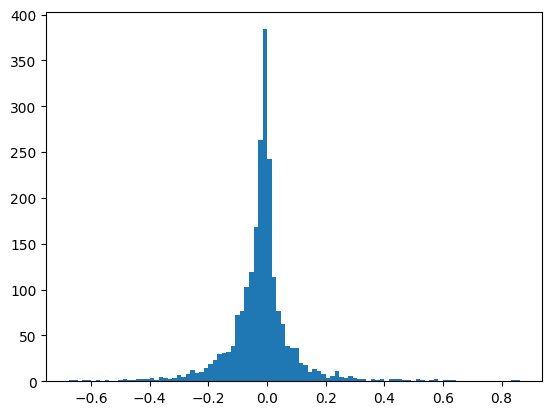

In [39]:
plot_stats(spelled_eq_steps_o1, steps_o1)

T-statistic: -8.5750 (Critical value 1.9623)
P-value: 0.000000
Result: Statistically significant
Interpretation: The result is statistically significant (reject the null hypothesis).

Relative mean change: -0.0631644881453293
Relative std change: 0.23293801946192413



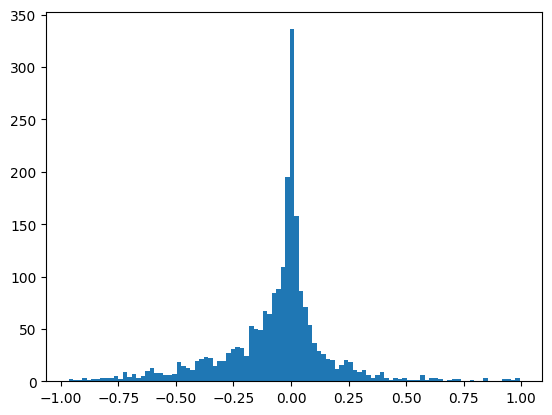

In [40]:
plot_stats(spelled_eq_steps_qwen_prm, steps_qwen_prm)

---

In [3]:
import matplotlib.pyplot as plt

def row_display(row):
    print("Split:", row["split"])
    print("Incorrect step:", row["label"])
    print("\nProcess rewards\n============\n")
    print("Error Step:".ljust(32), "  ".join(["  X  " if idx==row["label"] else "     " for idx in range(row["steps_len"])]))
    print("Qwen2.5-Math-PRM-7B:".ljust(32),   ", ".join([str(round(x, 3)).ljust(5) for x in row["Qwen2.5-Math-PRM-7B"]]))
    print("Skywork-o1-Open-PRM-Qwen-2.5-7B:", ", ".join([str(round(x, 3)).ljust(5) for x in row["Skywork-o1-Open-PRM-Qwen-2.5-7B"]]))

def row_plot(row):
    steps = list(range(row["steps_len"]))
    
    plt.figure(figsize=(10, 5))
    
    plt.plot(steps, row["Qwen2.5-Math-PRM-7B"], marker='o', label="Qwen2.5-Math-PRM-7B")
    plt.plot(steps, row["Skywork-o1-Open-PRM-Qwen-2.5-7B"], marker='s', label="Skywork-o1-Open-PRM-Qwen-2.5-7B")
    
    error_step = row["label"]
    if error_step!=-1:
        plt.axvline(x=error_step, color='red', linestyle='--', label='Incorrect Step')

    plt.title(f"Process Rewards — Split: {row['split']} | ID: {row['id']} | Final Answer Correct: {row['final_answer_correct']}")
    plt.xlabel("Step")
    plt.ylabel("Reward")
    plt.xticks(steps)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [6]:
def row_plot_length(row):
    steps = list(range(row["steps_len"]))
    
    plt.figure(figsize=(10, 5))
    
    # Define lines and labels
    # lines = [
    #     ("steps", "Qwen2.5-Math-PRM-7B"),
    #     ("verbose_steps", "Qwen2.5-Math-PRM-7B--verbose_steps"),
    #     ("consise_steps", "Qwen2.5-Math-PRM-7B--consise_steps"),
    # ]
    lines = [
        ("steps", "Skywork-o1-Open-PRM-Qwen-2.5-7B"),
        ("verbose_steps", "Skywork-o1-Open-PRM-Qwen-2.5-7B--verbose_steps"),
        ("consise_steps", "Skywork-o1-Open-PRM-Qwen-2.5-7B--consise_steps"),
    ]

    # Plot each line
    for step_col, reward_col in lines:
        y_values = row[reward_col]
        plt.plot(steps, y_values, marker="o", label=reward_col)
        
        # Annotate each point ON the plotted line
        steps_text = row[step_col]
        for (x, y, text) in zip(steps, y_values, steps_text):
            plt.text(x, y, len(text), fontsize=8, ha='left', va='bottom')

    # Add vertical line for error step
    error_step = row["label"]
    if error_step != -1:
        plt.axvline(x=error_step, color='red', linestyle='--', label='Incorrect Step')

    plt.title(f"Process Rewards — Split: {row['split']} | ID: {row['id']} | Final Answer Correct: {row['final_answer_correct']}")
    plt.xlabel("Step")
    plt.ylabel("Reward")
    plt.xticks(steps)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()


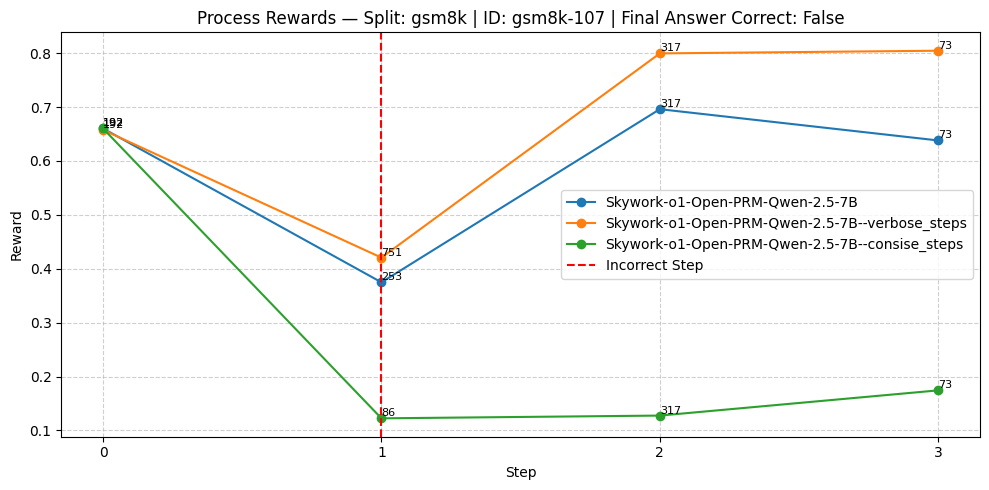

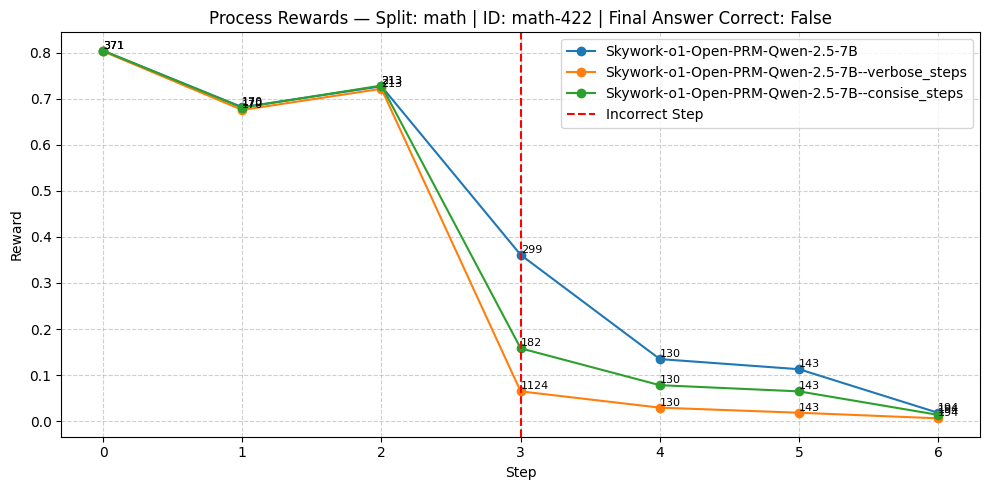

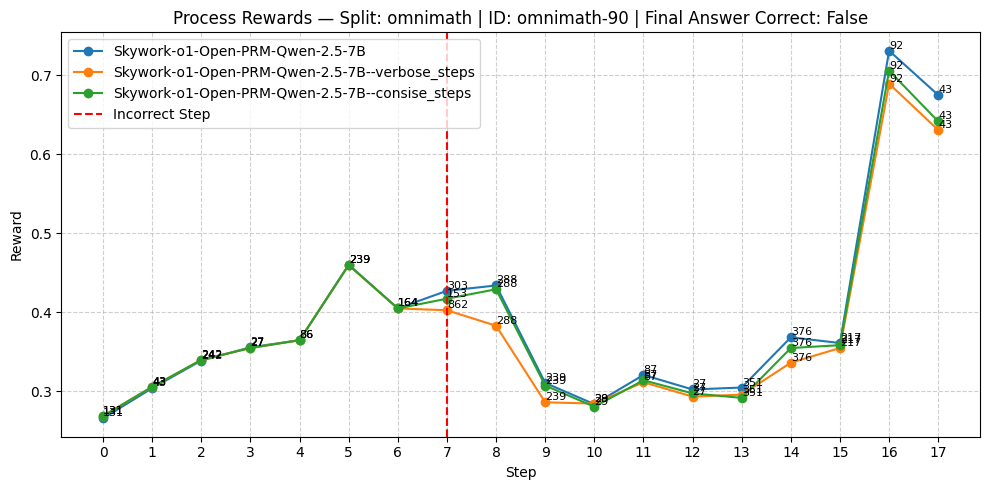

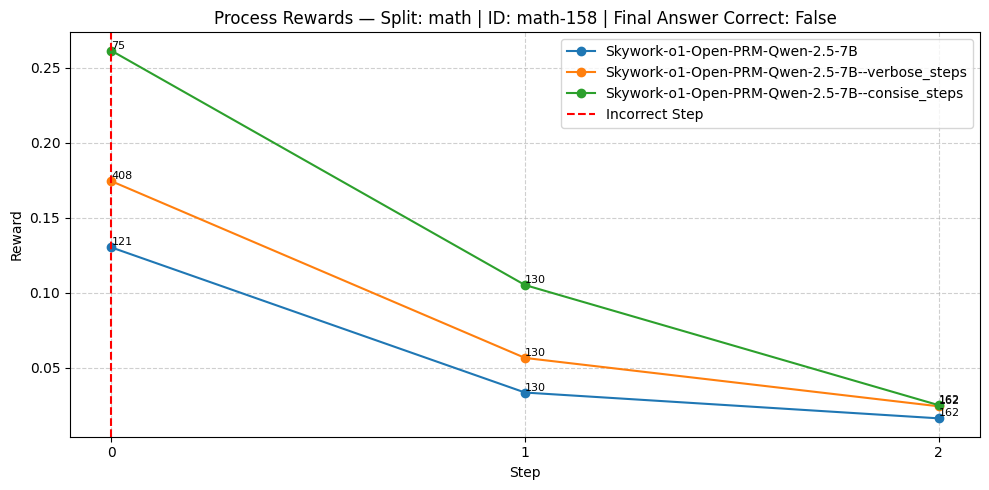

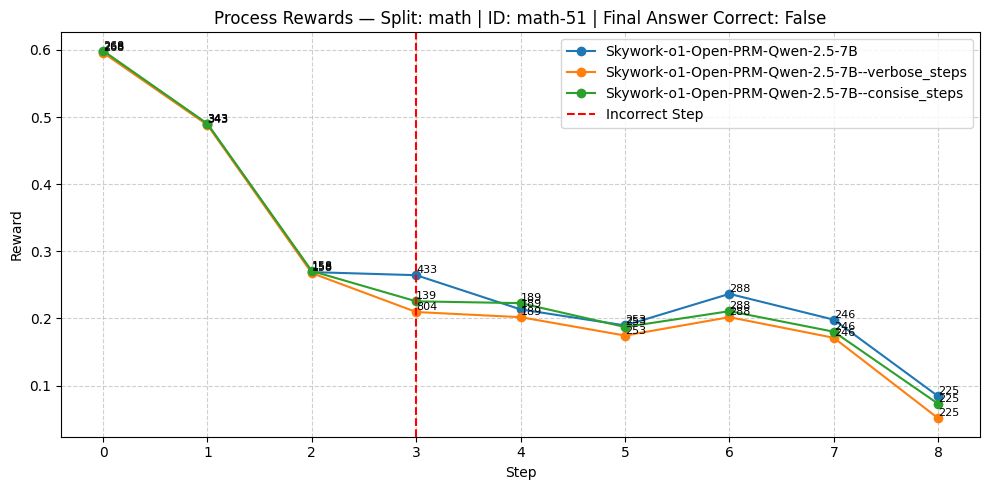

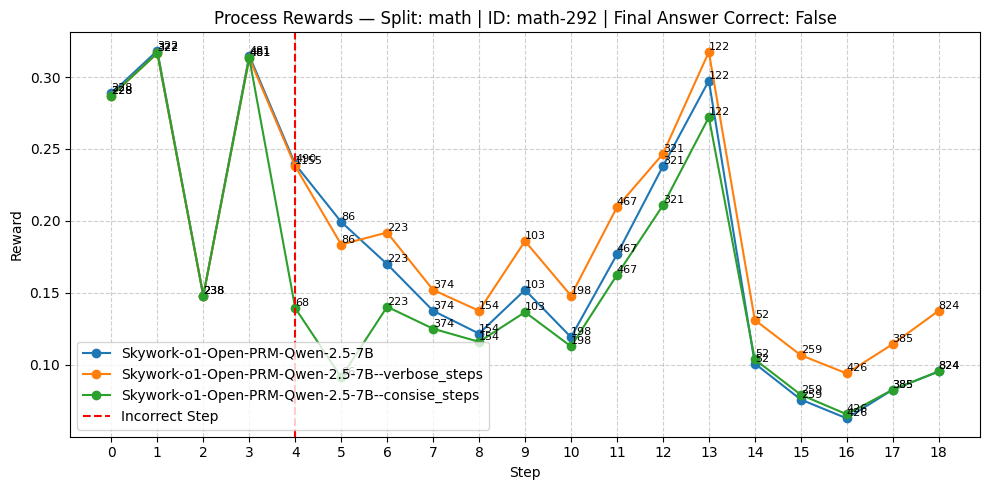

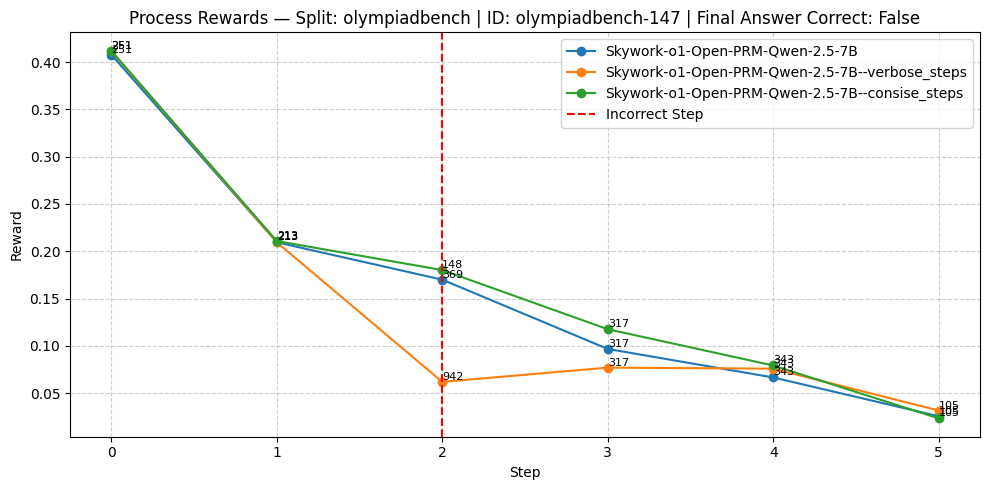

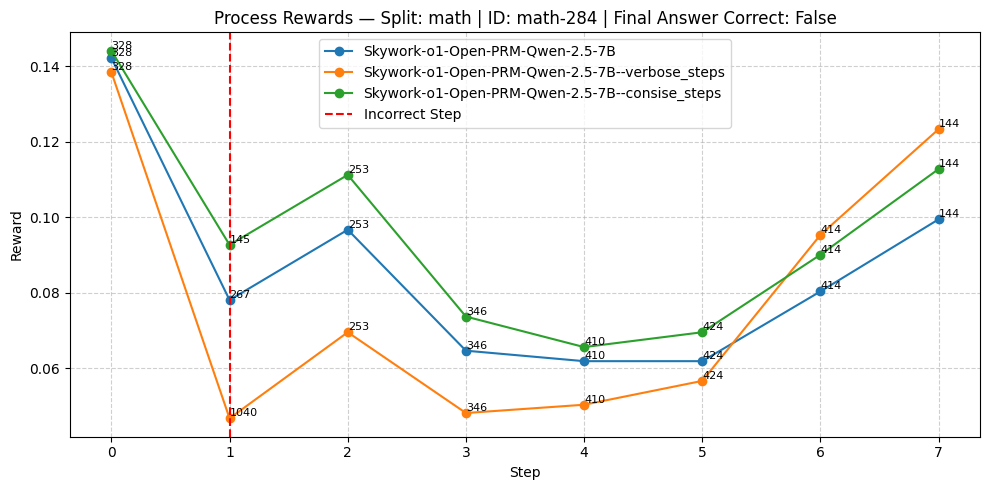

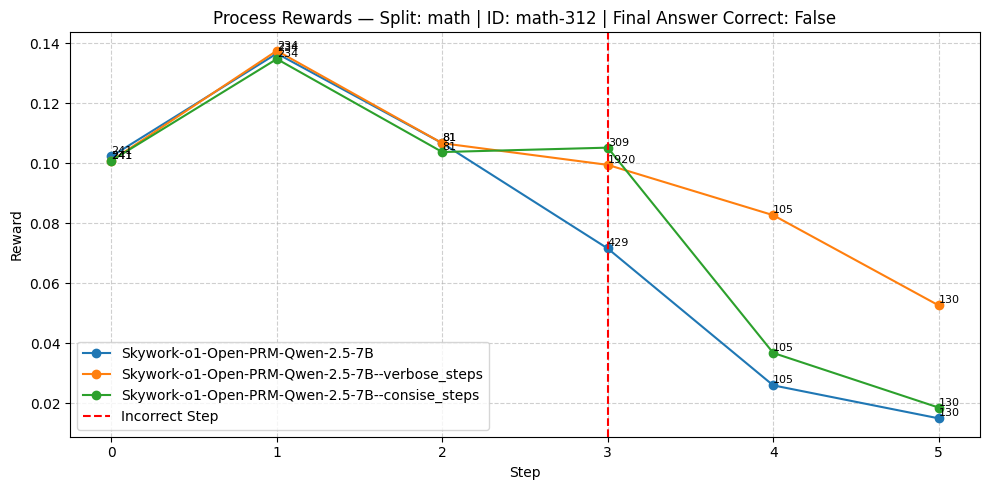

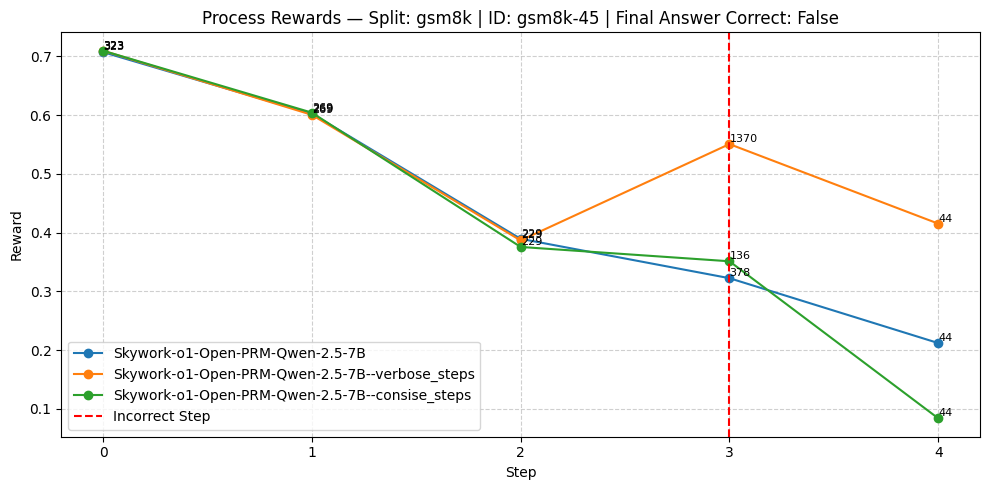

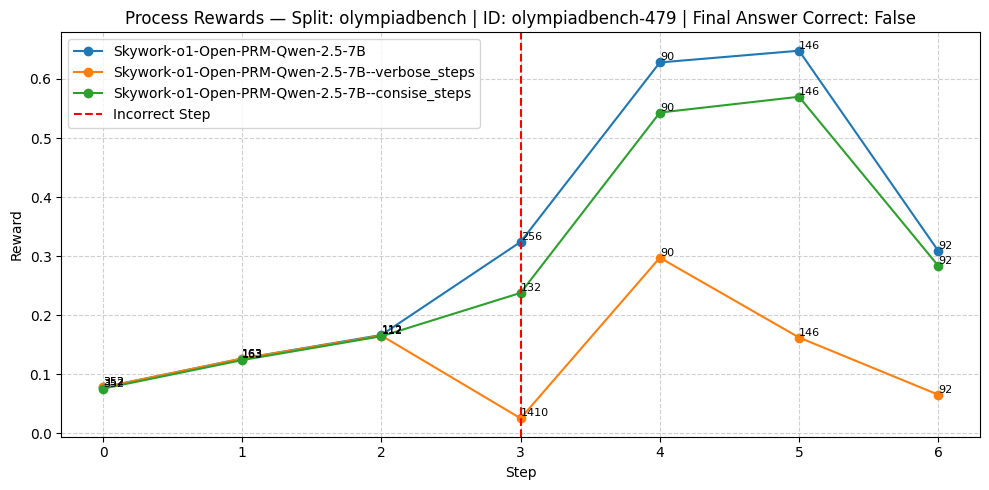

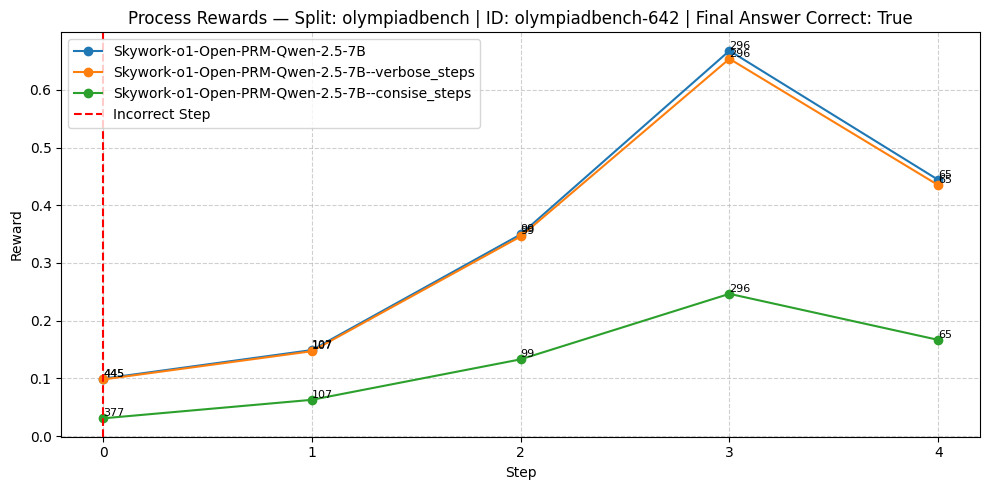

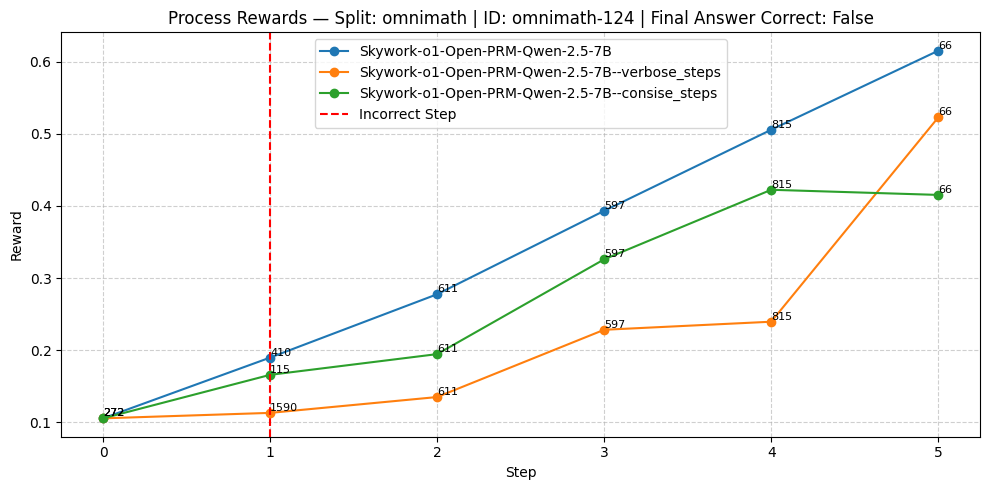

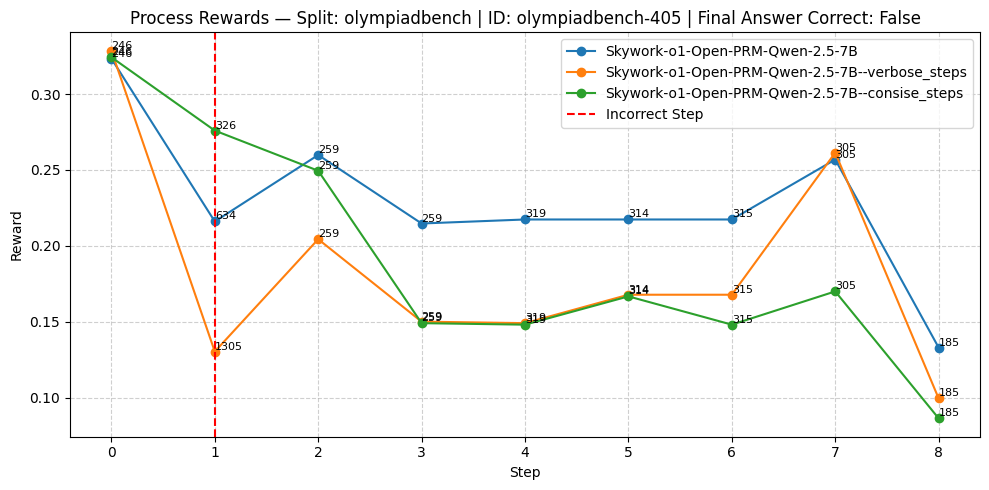

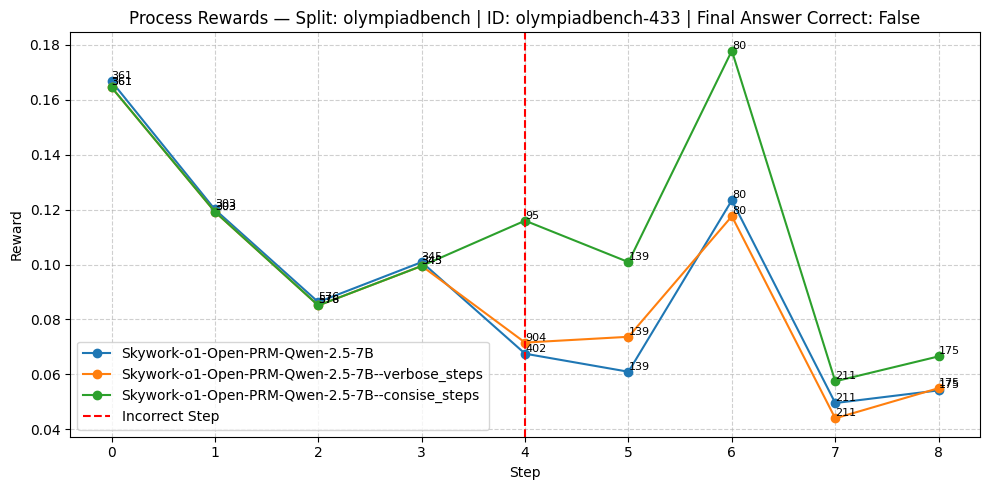

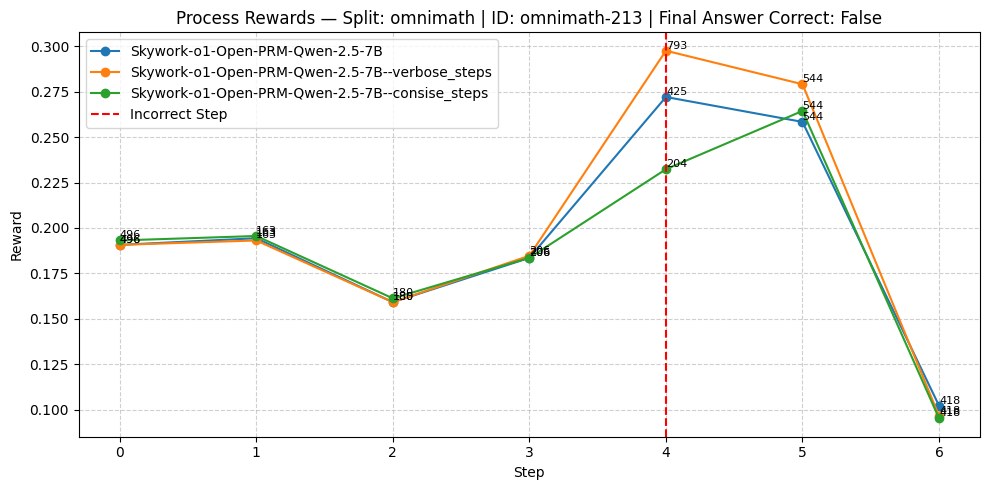

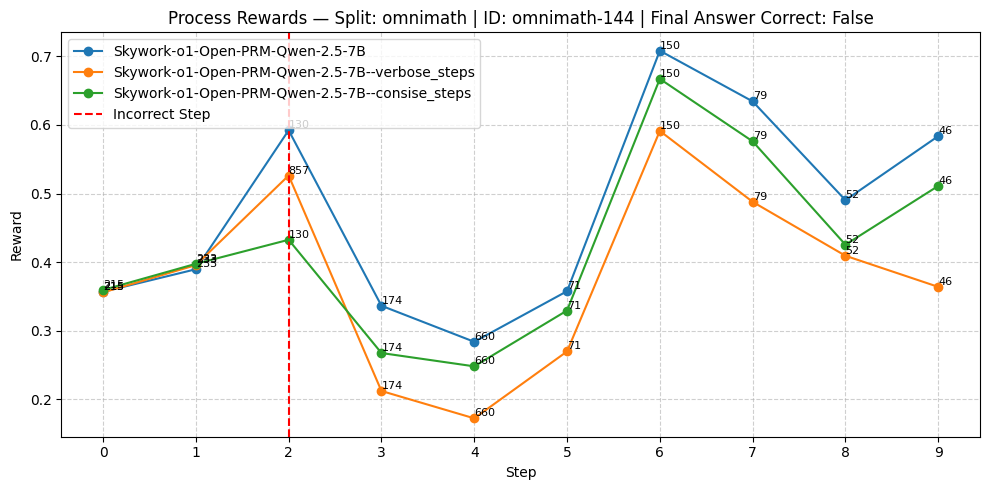

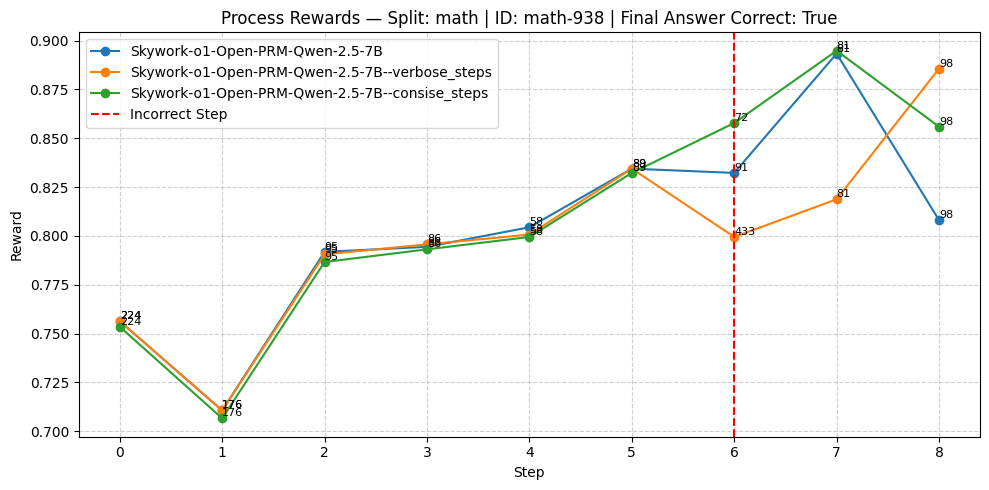

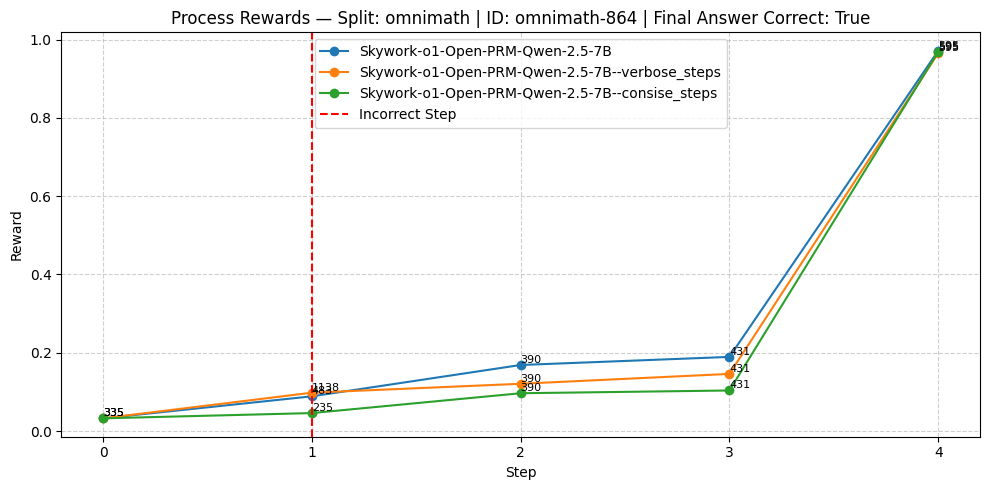

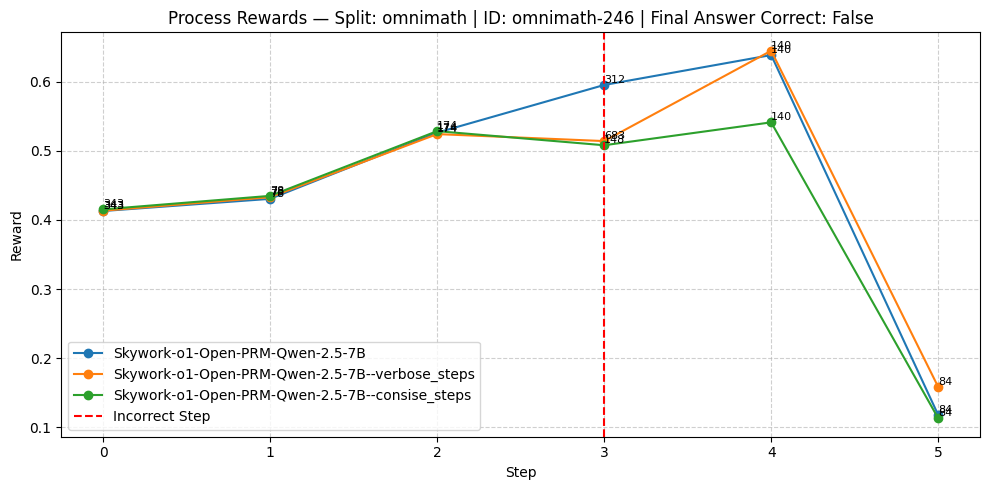

In [7]:
for idx, row in df[df["label"]!=-1].sample(20).iterrows():
    row_plot_length(row)

---

In [82]:
df_groupby = df.groupby(["label", "steps_len"])["Qwen2.5-Math-PRM-7B"].apply(list).reset_index(drop=False)

In [83]:
df_groupby["mean"] = df_groupby["Qwen2.5-Math-PRM-7B"].apply(lambda x: np.mean(x, 0))
df_groupby["var"] = df_groupby["Qwen2.5-Math-PRM-7B"].apply(lambda x: np.var(x, 0))
df_groupby["count"] = df_groupby["Qwen2.5-Math-PRM-7B"].apply(lambda x: len(x))
df_groupby["var_max"] = df_groupby["var"].apply(max)

<Axes: >

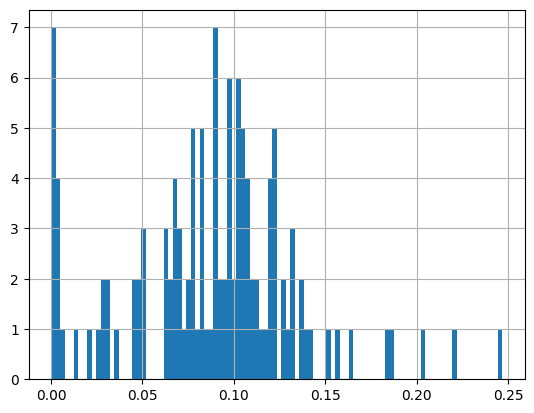

In [133]:
df_groupby[(df_groupby.label!=-1) & (df_groupby["count"]>1)].T.apply(lambda x: x["var"][x["label"]]).hist(bins=100)